# How the retail-attention signal works

This notebook explains, from the raw forum post to the call on the
dashboard, how the system is built and how it was tested. It is written
for a reader who has not seen the code. Every number and picture below is
recomputed from the project's own data when the notebook runs, so the text
and the evidence cannot drift apart.

**In one paragraph.** Public finance forums (Reddit, StockTwits, X) are
read twice a week. Each post is reduced to which tickers and themes it
talks about and how positive it sounds; the text itself is never kept in
the shared data. From those daily counts a handful of "how loud and how
bullish is the crowd, compared with its own normal" features are built
for each theme ETF and single name. A model trained on past manias scores
each name every day, and when the score crosses a cut that was fixed on
earlier years, the dashboard raises **INCREASE EXPOSURE** (the crowd is
arriving and the run is likely to continue) or **CUT EXPOSURE** (the run
is mature and the crowd looks like a top). All of the testing is
walk-forward: a year is only ever scored by a model fitted on the years
before it.

Contents

1. From posts to numbers: finding tickers, screening bots and duplicates, appending to the tables
2. Sentiment
3. The features, and how they were chosen (AUROC, ablation, noise, rank correlation)
4. What is being predicted: the price move that defines a mania
5. The models: logistic regression, gradient boosting, and the ensemble
6. From a score to a signal: thresholds and the operating point
7. Performance
8. Appendix: a map of who replies to whom (used separately)

In [1]:
import json, os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)

# The project is <root>/Code (the Python tree), <root>/Data and this
# notebook under <root>/Reference Materials; find the root from wherever
# the kernel starts.
PROJECT = Path.cwd()
while not (PROJECT / "Code" / "dashboard.py").exists() and PROJECT.parent != PROJECT:
    PROJECT = PROJECT.parent
CODE = PROJECT / "Code"
DATA = PROJECT / "Data"
sys.path.insert(0, str(CODE))
os.chdir(CODE)

RECORD = DATA / "research_record"
PROCESSED = DATA / "processed"
ABSTRACTED = DATA / "abstracted"

def record(name):
    with open(RECORD / name, encoding="utf-8") as f:
        return json.load(f)

INK, NAVY, TEAL, BRICK, GREY = "#111111", "#0A1E2E", "#1F6F5C", "#A6413B", "#9A9A9A"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 9})
print("project root:", PROJECT)

project root: /root/prod


## 1. From posts to numbers

### 1.1 Which tickers does a post talk about?

A post mentions a company either as a cashtag (`$NVDA`) or as a bare
upper-case word (`NVDA`). Cashtags are unambiguous. Bare words are not:
`EDGE`, `LOAN`, `RENT`, `AI` and hundreds of other tickers are also
ordinary English words, and counting every "edge" as a mention of the
ticker EDGE would swamp the data with noise.

Two signals decide whether a bare word counts (`Code/src/screen_tickers.py`):

* **How people actually type it.** On the forums, real tickers are written
  in capitals ("bought NVDA calls") and words are written in lower case
  ("the edge of the market"). The share of upper-case sightings is
  measured on the project's own corpus; a low share means it is a word.
* **How common the word is in English.** When the corpus has too few
  sightings to trust the first signal, the `wordfreq` package supplies a
  general-English frequency (a Zipf score: about 4–5 for an everyday word,
  under 3 for something that is not a word). A frequent English word is
  demoted.

A demoted ticker is not deleted: its cashtag mentions still count, only
the bare-word mentions stop. The extractor also carries an explicit
stop-list (`Code/config/ticker_stoplist.csv`) and an allow-list of short
tickers that must count without a `$` (`Code/config/ticker_allowlist.csv`).

In [2]:
from wordfreq import zipf_frequency

examples = ["edge", "loan", "rent", "snap", "amd", "nvda", "tsla", "pltr"]
tbl = pd.DataFrame({"word": [e.upper() for e in examples],
                    "Zipf frequency in English": [round(zipf_frequency(e, "en"), 2)
                                                  for e in examples]})
tbl["reads as"] = np.where(tbl["Zipf frequency in English"] >= 3.5,
                           "an English word (needs a $ or corpus evidence)",
                           "not a word (bare mention counts)")
tbl

,word,Zipf frequency in English,reads as
0,EDGE,4.74,an English word (needs a $ or corpus evidence)
1,LOAN,4.68,an English word (needs a $ or corpus evidence)
2,RENT,4.58,an English word (needs a $ or corpus evidence)
3,SNAP,4.21,an English word (needs a $ or corpus evidence)
4,AMD,3.52,an English word (needs a $ or corpus evidence)
5,NVDA,2.07,not a word (bare mention counts)
6,TSLA,2.26,not a word (bare mention counts)
7,PLTR,0.00,not a word (bare mention counts)


The corpus evidence always wins over the dictionary when both exist:
`AMD` and `SNAP` look like words to the dictionary but are typed in
capitals on the forums, so they are kept as tickers. The final decision
per ticker is stored in `Data/reference/ticker_classification.csv`.

### 1.2 Screening out bots and duplicates

Before anything is counted, every post gets a bot score in [0, 1]
(`Code/ingestion/bot_screen.py`). The score is a weighted sum of five plain
signals, and a post at or above the threshold (0.6 by default) is left
out of the aggregates. It stays in the raw store, so the decision is
reversible.

| Signal | Weight | What it catches |
|---|---|---|
| near-duplicate text | 0.55 | a post that is a near copy of another post (a different author, or the same author earlier). Found with MinHash locality-sensitive hashing over word 3-grams, Jaccard similarity ≥ 0.85. Texts under 8 words are never called duplicates. |
| burst | 0.45 | an author posting 12+ times in one day |
| self-declared bot | 1.00 | "I am a bot", "this action was performed automatically", AutoModerator, names ending in "bot" |
| low diversity | 0.35 | an author with 5+ posts whose texts are near-identical to each other (templated posting) |
| deleted author | 0.10 | a weak signal on its own; only tips a borderline case |

Near-duplicate detection is the workhorse: copy-pasted promotion is the
most common bot signature. The screen needs no model and is fully
explainable, and the exclusion rate is printed on every run.

In [3]:
from ingestion.bot_screen import screen_posts, WEIGHTS

demo = pd.DataFrame({
    "id": [f"p{i}" for i in range(6)],
    "author": ["alice", "bob", "promo_acct_1", "promo_acct_2", "AutoModerator", "[deleted]"],
    "date": pd.to_datetime(["2026-06-01"] * 6),
    "title": ["NVDA earnings tonight, holding through",
              "thinking about trimming my semis position after this run",
              "This under the radar gem is about to explode, do not miss the next 10x, load up now before the crowd",
              "This under the radar gem is about to explode, do not miss the next 10x, load up now before the crowd",
              "This action was performed automatically. Please contact the moderators.",
              "anyone else in URA"],
    "selftext": [""] * 6,
})
scored = screen_posts(demo)
scored[["author", "title", "bot_score", "bot_reasons"]].assign(
    title=lambda d: d["title"].str.slice(0, 60))

,author,title,bot_score,bot_reasons
0,alice,"NVDA earnings tonight, holding through",0.00,
1,bob,thinking about trimming my semis position afte...,0.00,
2,promo_acct_1,"This under the radar gem is about to explode, ...",0.55,near_duplicate
3,promo_acct_2,"This under the radar gem is about to explode, ...",0.55,near_duplicate
4,AutoModerator,This action was performed automatically. Pleas...,1.00,disclosed
5,[deleted],anyone else in URA,0.10,deleted_author


### 1.3 Appending to the tables

Nothing downstream ever reads post text. Each run reduces the surviving
posts to six daily tables and merges them into `Data/abstracted/`, which
is the only data folder committed to the repository:

| Table | One row per | Columns |
|---|---|---|
| `daily_ticker_counts` | ticker-day | mention count |
| `daily_ticker_counts_by_source` | ticker-day-source | mention count, split Reddit / StockTwits / X |
| `daily_ticker_sentiment` | ticker-day | number of posts, average sentiment, bullish-minus-bearish share |
| `daily_theme_counts` | theme-day | mention count |
| `daily_theme_sentiment` | theme-day | as above, per theme |
| `daily_term_counts` | term-day | vocabulary counts |

The merge is additive: counts add, and sentiment means recombine weighted
by the number of posts. Because there are no post ids in the tables, the
one thing that prevents a post from being added twice is a local ledger
of ids already folded (`Data/reference/abstracted_seen_ids.parquet`); a
post seen before is skipped, so running the fold twice adds nothing the
second time. History is never revised, only extended.

A theme is a list of keywords and tickers in `Code/config/` (for example
`uranium_nuclear` = URA, CCJ, UEC, ... plus words like "uranium",
"enrichment"); a post counts towards a theme when it matches any of them.
Each theme is represented by one ETF whose price is used for the ground
truth (section 4).

In [4]:
tables = ["daily_ticker_counts", "daily_ticker_sentiment",
          "daily_theme_counts", "daily_theme_sentiment"]
rows = []
for t in tables:
    p = ABSTRACTED / f"{t}.parquet"
    if p.exists():
        df = pd.read_parquet(p)
        rows.append({"table": t, "rows": len(df),
                     "first day": str(df["date"].min().date()),
                     "last day": str(df["date"].max().date()),
                     "columns": ", ".join(df.columns)})
pd.DataFrame(rows)

,table,rows,first day,last day,columns
0,daily_ticker_counts,452445,2017-01-01,2026-08-21,"date, ticker, mention_count"
1,daily_ticker_sentiment,452445,2017-01-01,2026-08-21,"date, ticker, n_posts, avg_sentiment, net_bullish"
2,daily_theme_counts,121678,2017-01-01,2026-08-21,"date, theme, mention_count"
3,daily_theme_sentiment,121678,2017-01-01,2026-08-21,"date, theme, n_posts, avg_sentiment, net_bullish"


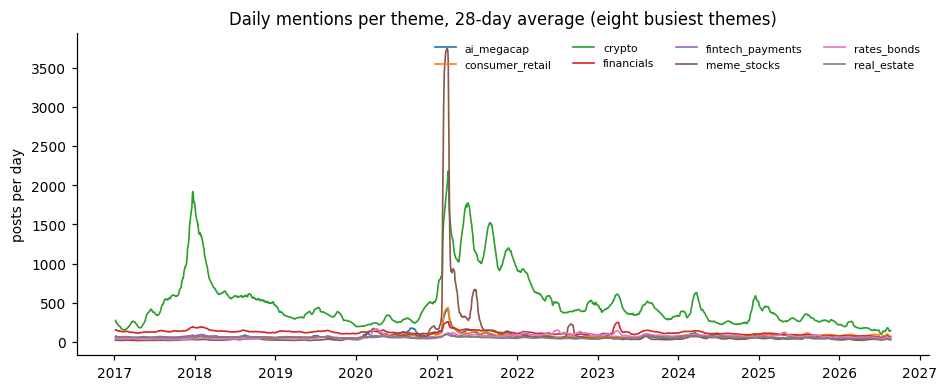

In [5]:
tc = pd.read_parquet(ABSTRACTED / "daily_theme_counts.parquet")
top = tc.groupby("theme")["mention_count"].sum().sort_values(ascending=False).head(8)
piv = (tc[tc["theme"].isin(top.index)]
       .pivot_table(index="date", columns="theme", values="mention_count", aggfunc="sum")
       .fillna(0).rolling(28, min_periods=7).mean())
fig, ax = plt.subplots(figsize=(10, 3.8))
for c in piv.columns:
    ax.plot(piv.index, piv[c], lw=1.1, label=c)
ax.set_title("Daily mentions per theme, 28-day average (eight busiest themes)")
ax.set_ylabel("posts per day")
ax.legend(ncol=4, fontsize=7, frameon=False)
plt.show()

## 2. Sentiment

Each post is scored once with **VADER**, a dictionary-based sentiment
scorer built for short social-media text. Every word in its dictionary
carries a valence; negation flips it ("not good" scores below zero) and
intensifiers scale it ("very good" above "good"). The output is a
*compound* score in [−1, +1].

Plain VADER misreads finance. "Calls" and "puts" are neutral to it,
"short" reads as generically negative, "moon" and "tendies" mean nothing.
The project layers two things on top (`Code/src/sentiment.py`): the FinVADER
financial dictionaries, and a hand-set slang lexicon (`moon` +2.5,
`bullish` +2.5, `puts` −1.5, `bagholder` −2, and so on, on VADER's roughly
−4 to +4 word scale). Long posts are cut at 300 characters because the
score saturates within the first few hundred characters.

Per day and per ticker or theme, the post scores are rolled up into

* `avg_sentiment` — the mean compound score, and
* `net_bullish` — the share of bullish posts (compound > +0.05) minus the
  share of bearish posts (compound < −0.05).

`net_bullish` is the headline measure: one extreme post cannot drag it,
and it reads naturally (+0.30 means thirty points more bulls than
bears). Sarcasm and irony defeat any dictionary, so the features in
section 3 never use the level on its own; they compare a name's mood
with its own history and look for changes.

In [6]:
from src.sentiment import score_text
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
plain = SentimentIntensityAnalyzer()

texts = ["NVDA to the moon, loaded up on calls",
         "this thing is a dumpster fire, puts printing",
         "not convinced the rally holds, trimming",
         "bought more, diamond hands, bullish",
         "AutoModerator: your post has been removed"]
pd.DataFrame({"text": texts,
              "plain VADER": [round(plain.polarity_scores(t)["compound"], 3) for t in texts],
              "with finance lexicon (used)": [round(score_text(t), 3) for t in texts]})

sentiment engine: finvader+wsb (13,353 lexicon terms)


,text,plain VADER,with finance lexicon (used)
0,"NVDA to the moon, loaded up on calls",0.000,0.818
1,"this thing is a dumpster fire, puts printing",-0.459,-0.166
2,"not convinced the rally holds, trimming",-0.309,-0.123
3,"bought more, diamond hands, bullish",0.401,0.619
4,AutoModerator: your post has been removed,0.000,0.000


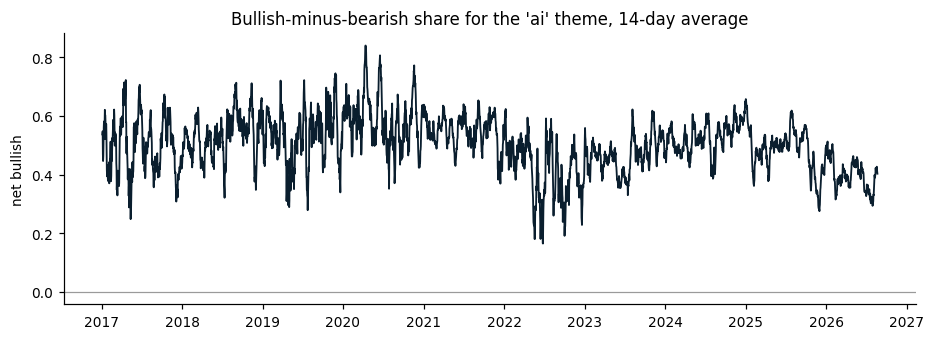

In [7]:
ts = pd.read_parquet(ABSTRACTED / "daily_theme_sentiment.parquet")
name = "ai" if "ai" in set(ts["theme"]) else ts["theme"].iloc[0]
s = ts[ts["theme"] == name].set_index("date").sort_index()
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(s.index, s["net_bullish"].rolling(14, min_periods=5).mean(), color=NAVY, lw=1.2)
ax.axhline(0, color=GREY, lw=0.8)
ax.set_title(f"Bullish-minus-bearish share for the '{name}' theme, 14-day average")
ax.set_ylabel("net bullish")
plt.show()

## 3. The features, and how they were chosen

### 3.1 What a feature is

A feature is one number per name per day that answers a question like
"how loud is the crowd about this name today, compared with its own
normal?". Every feature is:

* **trailing** — day *t* uses only data up to day *t*, so nothing can
  peek at the future; and
* **a percentile rank against the same name's own history** — a value of
  0.90 means "louder than 90 % of this name's own past days". Ranks are
  robust to fat tails and to the fact that forum coverage grew over the
  years (a raw count of 500 posts meant something different in 2019 and
  in 2026; "in its own top decile" did not).

The production model uses eleven features: nine from the crowd and two
from price.

| Feature | Plain reading |
|---|---|
| `e1` attention level | how loud the name is versus its own last year |
| `e3` attention change (1 month) | is the crowd bigger than a month ago |
| `influx_speed` | is the crowd bigger than two weeks ago |
| `attention_accel` | is this week busier than this month |
| `hype_ratio` | this week versus the name's own 120-day norm |
| `attention_convexity` | is the *growth* of attention itself accelerating (the super-exponential signature of contagion) |
| `bull_level` | how bullish the mood is versus its own year |
| `bull_persist` | what fraction of the last month leaned bullish |
| `bull_inflection` | is the mood turning |
| `price_runup` | how far the price has run off its recent low |
| `price_ret21` | the one-month price return |

Price does not enter any crowd feature; the two price features were added
in a separate step and are reported separately below, because "the crowd
alone" and "the crowd plus where the price already is" are different
claims.

### 3.2 Does any one feature separate the good days from the rest? (AUROC)

AUROC answers: if you pick one day that turned out to be the start (or
the top) of a mania and one ordinary day, how often does the feature
rank the mania day higher? 0.5 is a coin flip, 1.0 is perfect. It is
computed on the candidate-day frame the model is fitted on — one row per
name per day with the features and two labels, `y_onset` (this day is
inside the first 45 days after a mania's trough) and `y_top` (this day is
inside the month before a mania's peak).

In [8]:
from sklearn.metrics import roc_auc_score, average_precision_score

frame = pd.read_parquet(PROCESSED / "phase_day_frame.parquet")
crowd = ["attention_accel", "hype_ratio", "bull_inflection", "influx_speed",
         "attention_convexity", "e1", "e2", "e3", "e5", "fade"]
crowd = [c for c in crowd if c in frame.columns]
print(f"{len(frame):,} candidate days, {frame['name'].nunique()} names, "
      f"{frame['date'].min().date()} to {frame['date'].max().date()}")

rows = []
for f in crowd:
    m = frame[f].notna()
    for lab in ("y_onset", "y_top"):
        rows.append({"feature": f, "label": lab,
                     "AUROC": roc_auc_score(frame.loc[m, lab], frame.loc[m, f])})
auc = pd.DataFrame(rows).pivot(index="feature", columns="label", values="AUROC").round(3)

# the two price features are recorded from the research pass that added them
bank_rec = pd.DataFrame(record("nb02_august_bank.json"))
price_auc = (bank_rec[bank_rec["column"].str.startswith("price")]
             .set_index("column")[["AUROC vs y_onset", "AUROC vs y_top"]]
             .rename(columns={"AUROC vs y_onset": "y_onset", "AUROC vs y_top": "y_top"}))
auc = pd.concat([auc, price_auc]).sort_values("y_top", ascending=False)
auc

61,872 candidate days, 54 names, 2017-08-27 to 2026-06-06


,y_onset,y_top
price_runup,0.761,0.767
price_ret21,0.672,0.696
e1,0.566,0.592
e2,0.476,0.560
hype_ratio,0.554,0.557
e5,0.545,0.540
attention_convexity,0.545,0.540
e3,0.567,0.537
influx_speed,0.538,0.534
attention_accel,0.538,0.525


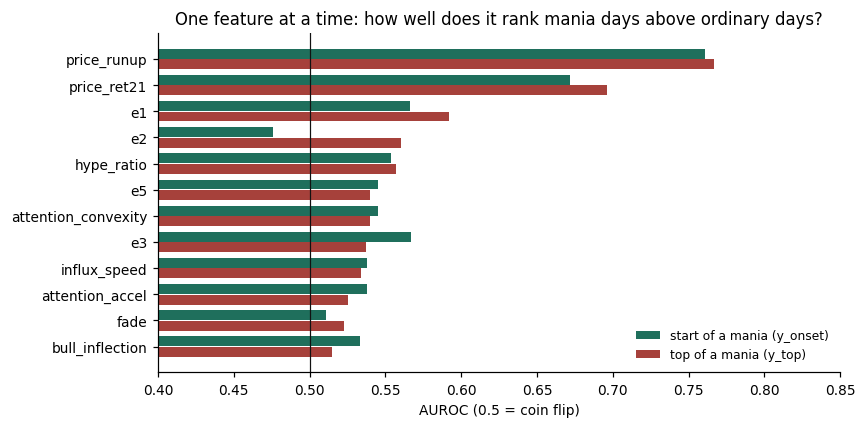

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(auc))
ax.barh(y - 0.2, auc["y_onset"], height=0.38, color=TEAL, label="start of a mania (y_onset)")
ax.barh(y + 0.2, auc["y_top"], height=0.38, color=BRICK, label="top of a mania (y_top)")
ax.axvline(0.5, color=INK, lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(auc.index); ax.invert_yaxis()
ax.set_xlim(0.4, 0.85); ax.set_xlabel("AUROC (0.5 = coin flip)")
ax.set_title("One feature at a time: how well does it rank mania days above ordinary days?")
ax.legend(frameon=False, fontsize=8)
plt.show()

**What this says.** No single crowd feature is a detector on its own: the
crowd features sit in the 0.50–0.60 band. The two price features are
much stronger (0.67–0.77), which is expected — a mania is *defined* by a
price run, so "how far has the price run" is close to the label by
construction. This is why the crowd features are used together as a
committee, and why the report in section 7 keeps a crowd-only variant
beside the production model: it is the honest measure of what the crowd
alone can see.

### 3.3 Is any one feature carrying the bank? (ablation)

Ablation removes one feature at a time from an equal-weight bank and
measures what the bank loses. If one feature were doing all the work,
removing it would collapse the score.

In [10]:
onset_bank = ["attention_accel", "hype_ratio", "bull_inflection", "influx_speed", "attention_convexity"]
top_bank = ["e1", "e2", "e3", "e5", "fade"]

def bank_score(df, bank):
    return df[bank].mean(axis=1)

def ablation(bank, label):
    m = frame[bank + [label]].notna().all(axis=1)
    y = frame.loc[m, label].values
    base = average_precision_score(y, bank_score(frame[m], bank))
    out = [{"bank": label, "variant": "full bank", "AP": base, "change": 0.0}]
    for f in bank:
        rest = [b for b in bank if b != f]
        ap = average_precision_score(y, bank_score(frame[m], rest))
        out.append({"bank": label, "variant": f"without {f}", "AP": ap, "change": ap - base})
    return pd.DataFrame(out).round(4)

abl = pd.concat([ablation(onset_bank, "y_onset"), ablation(top_bank, "y_top")])
abl["bank"] = abl["bank"].map({"y_onset": "start bank (y_onset)", "y_top": "top bank (y_top)"})
abl.set_index(["bank", "variant"])

AP  change
bank                 variant                                    
start bank (y_onset) full bank                    0.0842  0.0000
                     without attention_accel      0.0831 -0.0011
                     without hype_ratio           0.0850  0.0008
                     without bull_inflection      0.0813 -0.0029
                     without influx_speed         0.0831 -0.0011
                     without attention_convexity  0.0806 -0.0037
top bank (y_top)     full bank                    0.0896  0.0000
                     without e1                   0.0861 -0.0035
                     without e2                   0.0784 -0.0112
                     without e3                   0.0916  0.0019
                     without e5                   0.0805 -0.0091
                     without fade                 0.0963  0.0066

Removing any one feature moves average precision by a few thousandths.
The bank is a committee, not one good feature plus passengers — which is
what a live system needs, because it degrades gently if one input
misbehaves rather than failing outright. No feature earned removal on
these numbers; the choice of the final bank was left to the model
tournament in section 5, which judges whole models walk-forward.

### 3.4 What happens when an input goes bad? (Gaussian noise)

In production the inputs will not always be clean: a scraper misses a
day, a platform changes its API. This test corrupts one feature at a
time by adding Gaussian noise (every feature is a 0–1 percentile, so a
standard deviation of 0.10 means "typically ten percentile points off the
truth"; 0.40 is closer to destroyed than degraded), clips it back into
[0, 1], re-scores the bank, and records the loss in average precision,
averaged over several random draws.

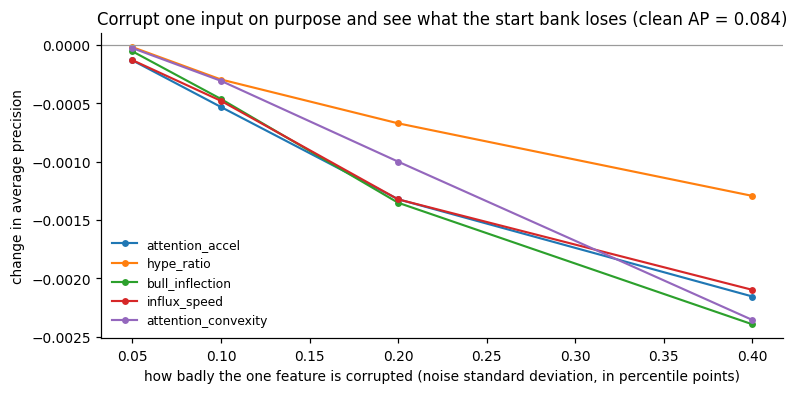

most damaging input to lose: bull_inflection (-0.0024 AP at the heaviest noise)


In [11]:
def perturbation(bank, label, sigmas=(0.05, 0.1, 0.2, 0.4), n_draws=8):
    m = frame[bank + [label]].notna().all(axis=1)
    sub = frame.loc[m, bank].copy(); y = frame.loc[m, label].values
    base = average_precision_score(y, sub.mean(axis=1))
    out = {}
    for f in bank:
        losses = []
        for s in sigmas:
            aps = []
            for d in range(n_draws):
                rng = np.random.default_rng(1000 * d + int(100 * s))
                noisy = sub.copy()
                noisy[f] = (noisy[f] + rng.normal(0, s, len(noisy))).clip(0, 1)
                aps.append(average_precision_score(y, noisy.mean(axis=1)))
            losses.append(np.mean(aps) - base)
        out[f] = losses
    return base, list(sigmas), out

base, sigmas, curves = perturbation(onset_bank, "y_onset")
fig, ax = plt.subplots(figsize=(8, 3.6))
for f, ys in curves.items():
    ax.plot(sigmas, ys, "o-", lw=1.4, ms=3.5, label=f)
ax.axhline(0, color=GREY, lw=0.8)
ax.set_xlabel("how badly the one feature is corrupted (noise standard deviation, in percentile points)")
ax.set_ylabel("change in average precision")
ax.set_title(f"Corrupt one input on purpose and see what the start bank loses (clean AP = {base:.3f})")
ax.legend(frameon=False, fontsize=8)
plt.show()
worst = min(curves, key=lambda f: curves[f][-1])
print(f"most damaging input to lose: {worst} ({curves[worst][-1]:+.4f} AP at the heaviest noise)")

No input is a single point of failure: even at the heaviest corruption
the bank's precision falls by a modest amount rather than collapsing or
inverting. The steepest curve names the input to watch hardest in
production.

### 3.5 Are the features saying the same thing? (Spearman rank correlation)

Spearman's rank correlation measures whether two features move together
in rank order, without assuming a straight-line relationship. Two
features at +0.9 are nearly one feature counted twice; a bank of
near-duplicates is fragile and hard to read. The matrix also shows each
feature's rank correlation with the labels.

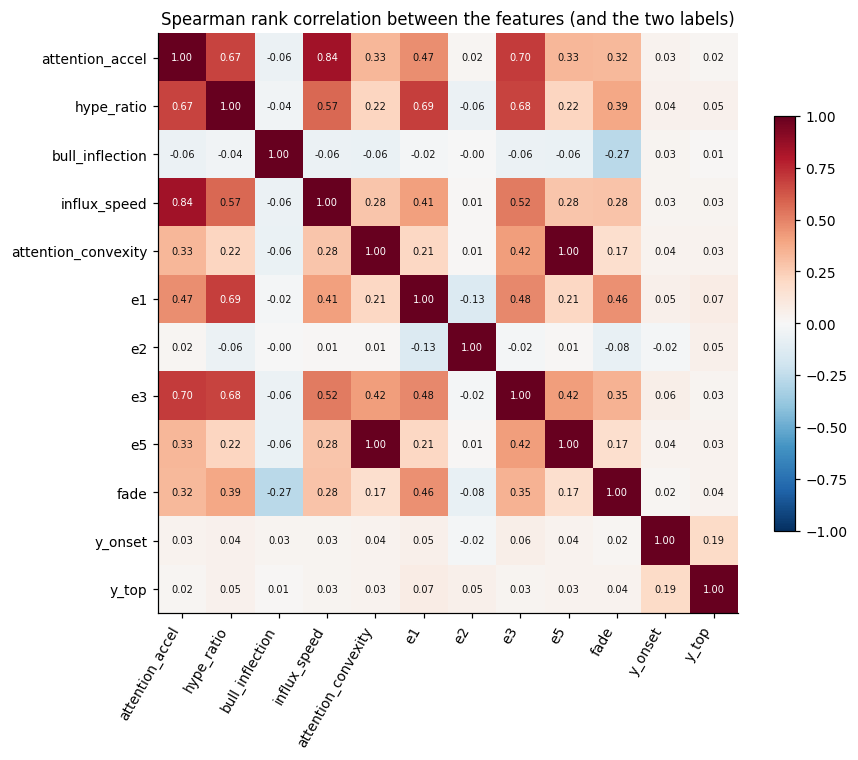

In [12]:
feats = onset_bank + top_bank + ["bull_level", "bull_persist"]
feats = [f for f in dict.fromkeys(feats) if f in frame.columns]
corr = frame[feats + ["y_onset", "y_top"]].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=60, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(corr.values[i, j]) > 0.6 else INK)
ax.set_title("Spearman rank correlation between the features (and the two labels)")
fig.colorbar(im, ax=ax, shrink=0.7)
plt.show()

The only strong pair is `e1` with `e3` (attention level with its
one-month change, both measuring the same crowd at different horizons).
Everything else is weakly related, so the bank is not counting one thing
many times. Correlations with the labels are small for every crowd
feature, consistent with the single-feature AUROCs: the crowd features
select candidates; the price, the gates and the model's combination do
the rest.

One feature was dropped by this kind of check: `source_breadth` (how many
of the platforms mentioned the name in the last week) looked skilful,
but StockTwits and X exist in the archive only from 2026, so the feature
mostly encoded *which year it is*. It was removed from the bank.

## 4. What is being predicted: the price move that defines a mania

The labels come from price alone, with the rule written down before any
crowd data was looked at. A **mania** (an "episode") is a run-up followed
by a bust:

* **G1** — the day is a local price maximum over ±21 days;
* **G2** — the close is at least **+20 % for a theme ETF** or **+40 % for a
  single name** above the lowest close of the preceding 120 days (the
  *boom bar*);
* **G3** — within the following 90 days the price falls at least 12 %
  (ETF) or 25 % (single name) from that peak (the *bust bar*).

Peaks closer than 30 days are merged. The **trough** is the 120-day low
the boom is measured from; the **start window** is the 45 days after the
trough; the **top window** is the month before the peak. A name is only
scorable on a day when it carries at least 100 scored posts in the last
28 days, so a crowd that cannot be seen is never diagnosed.

Single names get a higher bar because they are more volatile: a 20 %
swing is a routine month for a meme stock and a real event for a
sector ETF.

### 4.1 How rare is the boom bar?

The cell below measures, over every day of every tracked name, how far
the price sits above its trailing 120-day low, and where the boom bar
falls in that distribution.

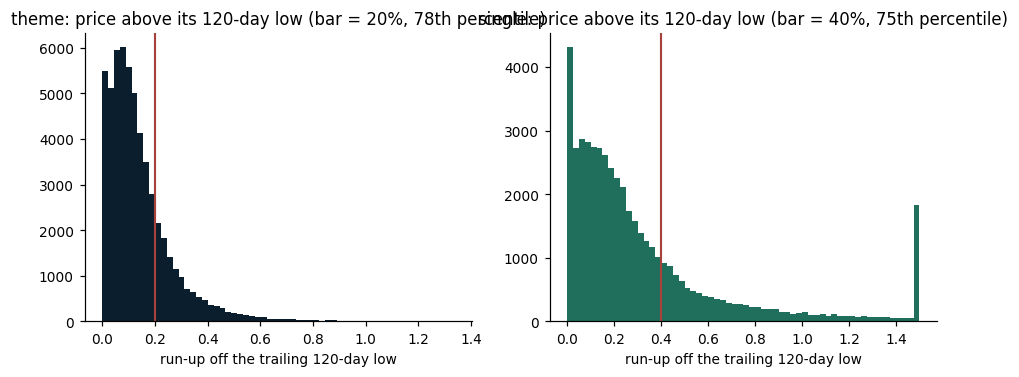

,kind,instruments,instrument-days,median run-up,share of days at or above the bar,the bar sits at percentile
0,theme,26,55924,0.111,0.221,77.9
1,single,24,47671,0.207,0.251,74.9


In [13]:
px = pd.read_parquet(DATA / "prices" / "prices.parquet")
uni = (pd.read_parquet(PROCESSED / "euphoria_desk.parquet", columns=["name", "symbol", "kind"])
       .drop_duplicates("symbol").set_index("symbol")["kind"])
runups = {"theme": [], "single": []}
for sym, g in px.groupby("symbol"):
    if sym not in uni.index:
        continue
    s = g.set_index("date")["px_last"].dropna().sort_index()
    if len(s) < 240:
        continue
    lo = s.rolling("120D", min_periods=60).min()
    runups[uni[sym]].append((s / lo - 1).dropna())

bars = {"theme": 0.20, "single": 0.40}
summary = []
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, kind in zip(axes, ("theme", "single")):
    v = pd.concat(runups[kind])
    pct = (v < bars[kind]).mean() * 100
    summary.append({"kind": kind, "instruments": len(runups[kind]), "instrument-days": len(v),
                    "median run-up": round(v.median(), 3),
                    "share of days at or above the bar": round(1 - pct / 100, 3),
                    "the bar sits at percentile": round(pct, 1)})
    ax.hist(v.clip(upper=1.5), bins=60, color=NAVY if kind == "theme" else TEAL)
    ax.axvline(bars[kind], color=BRICK, lw=1.4)
    ax.set_title(f"{kind}: price above its 120-day low (bar = {bars[kind]:.0%}, "
                 f"{pct:.0f}th percentile)")
    ax.set_xlabel("run-up off the trailing 120-day low")
plt.show()
pd.DataFrame(summary)

So the boom bar is not the median day: across the tracked universe it
sits around the **75th–80th percentile** of all instrument-days (about
one day in four or five is that far above its 120-day low), and the bust
that must follow makes a confirmed mania rarer still. The exact
percentile is printed above from the current price store.

### 4.2 What was found

In [14]:
eps = pd.read_parquet(PROCESSED / "episodes.parquet")
stats = record("nb01_episode_stats.json")
print(f"{len(eps)} episodes across {eps['name'].nunique()} names, "
      f"{eps['year'].min()}–{eps['year'].max()}")
print(f"median run-up trough→peak {eps['boom_pct'].median():.0%}, "
      f"median fall after the peak {eps['bust_pct'].median():.0%}, "
      f"median run {eps['run_days'].median():.0f} days")
print(f"detectable for the start head (enough crowd data at the time): {int(eps['onset_detectable'].sum())}; "
      f"for the top head: {int(eps['top_detectable'].sum())}")
per_year = eps.groupby("year").agg(episodes=("name", "size"),
                                   start_detectable=("onset_detectable", "sum"),
                                   top_detectable=("top_detectable", "sum"))
per_year.T

489 episodes across 52 names, 2017–2026
median run-up trough→peak 48%, median fall after the peak -27%, median run 93 days
detectable for the start head (enough crowd data at the time): 305; for the top head: 309


year,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
episodes,5,24,20,54,66,76,63,63,49,69
start_detectable,1,15,15,33,51,42,31,42,28,47
top_detectable,1,16,14,34,52,40,29,47,32,44


### 4.3 Why these bars and not others

The bars were swept: the whole evaluation was re-run under a stricter
definition (25 % / 50 % boom, 15 % / 30 % bust) and a looser one
(15 % / 30 %, 10 % / 20 %). The stricter one produces fewer, cleaner
episodes and a slightly higher AUROC but leaves most themes without a
single episode to learn from; the looser one produces many more
"episodes" that are ordinary volatility. The adopted bars are the middle
setting, and the model's ranking quality (AUROC) is stable across all
three, which is the point: the result does not hinge on the exact
threshold.

In [15]:
gts = record("ml_tournament.json")["ground_truth_sweep"]
pd.DataFrame([{"definition": k, "episodes": v["episodes"],
               "CUT: AUROC": v["get_out"]["auroc"], "CUT: episodes caught": v["get_out"]["capture_rate"],
               "INCREASE: AUROC": v["get_in"]["auroc"], "INCREASE: episodes caught": v["get_in"]["capture_rate"]}
              for k, v in gts.items()]).set_index("definition")

,episodes,CUT: AUROC,CUT: episodes caught,INCREASE: AUROC,INCREASE: episodes caught
definition,,,,,
"GT-old (25/50, 15/30)",292,0.742,0.361,0.763,0.538
"GT-ADOPTED (20/40, 12/25)",494,0.688,0.472,0.748,0.692
"GT-loosest (15/30, 10/20)",779,0.661,0.543,0.706,0.637


## 5. The models

Two heads are fitted on the same eleven features: one for the **start** of
a mania (`y_onset` → INCREASE EXPOSURE) and one for the **top**
(`y_top` → CUT EXPOSURE). Three model families were tried, each judged the
same way.

**Logistic regression (logit).** One weight per feature; the score is a
weighted sum passed through a sigmoid. Fully readable as a formula, and
it can only express "more of this feature always pushes the score the
same way".

**Gradient-boosted trees (GBM).** Two hundred shallow decision trees
(depth 3), each correcting the last, on sklearn's
`HistGradientBoostingClassifier`. Trees learn interactions the rules had
to hard-code ("hype only matters when attention is already high"). One
design choice keeps a 200-tree model presentable: every feature carries a
**monotone constraint**, so more crowd heat can only *raise* the score.
The model cannot learn "high attention is sometimes safe"; its behaviour
is globally directional like a rule, while the tree structure learns the
interactions.

**The ensemble (used).** Both models score every day; the two
probability *rankings* are averaged, so neither model's calibration
dominates. This is the production model. (A small neural network was
included as a ceiling check; it did not beat the GBM, which says the GBM
is capturing what is learnable.)

**Training is walk-forward.** For each test year from 2018 to 2026, the
model is fitted on every earlier year and scores the test year blind.
Classes are re-weighted so the rare mania days count as much as the many
ordinary days. Nothing in a live run re-fits: the model, its features and
its cut are frozen by a research pass and pinned by tests; a live run
only scores.

**The rule for picking the winner was written down before the numbers
were computed:** one family serves both heads, and the family with the
highest combined *lift* in average precision (test-year AP divided by
the base rate, summed over the two heads) wins; ties go to AUROC, then to
fewer false alarms. Lift rather than raw AP because the rule-based
baseline only scores days that already passed its gates, which inflates
its raw AP by construction.

In [16]:
res = record("ml_tournament.json")["results"]
rows = []
for fam in ("logit", "gbm", "mlp", "ens", "rules"):
    r = {"model": fam}
    lift = 0.0
    for head, label in (("get_in", "INCREASE"), ("get_out", "CUT")):
        v = res[head][fam]
        r[f"{label}: AUROC"] = v["auroc"]; r[f"{label}: AP"] = v["ap"]
        r[f"{label}: base rate"] = v["ap_baseline"]
        r[f"{label}: episodes caught"] = v["capture_rate"]
        r[f"{label}: false alarms / name-year"] = v["fa_per_iy"]
        lift += v["ap"] / v["ap_baseline"]
    r["combined AP lift"] = round(lift, 2)
    rows.append(r)
tour = pd.DataFrame(rows).set_index("model")
print("winner by the pre-stated rule:", res["winner"])
tour

winner by the pre-stated rule: ens


,INCREASE: AUROC,INCREASE: AP,INCREASE: base rate,INCREASE: episodes caught,INCREASE: false alarms / name-year,CUT: AUROC,CUT: AP,CUT: base rate,CUT: episodes caught,CUT: false alarms / name-year,combined AP lift
model,,,,,,,,,,,
logit,0.748,0.290,0.111,0.692,0.524,0.688,0.201,0.104,0.472,0.465,4.55
gbm,0.740,0.269,0.111,0.616,0.428,0.715,0.212,0.104,0.454,0.574,4.46
mlp,0.709,0.225,0.111,0.561,0.470,0.695,0.191,0.104,0.427,0.925,3.86
ens,0.750,0.283,0.111,0.566,0.235,0.717,0.255,0.104,0.422,0.346,5.00
rules,0.550,0.147,0.122,0.091,0.180,0.549,0.545,0.482,0.117,0.094,2.34


The ensemble wins on the pre-stated criterion, and it is also the family
with the fewest false alarms per name-year on both heads. The
"rules" row is the original hand-set gate stack it replaced: its raw AP
looks high because it only scores days that already passed its gates,
but its ranking quality (AUROC ≈ 0.55) is a coin flip.

### 5.1 The same models without price

For honesty, every family was also fitted on the nine crowd features
alone.

In [17]:
rows = []
for fam in ("logit", "gbm", "ens"):
    for suffix, label in (("_crowd", "crowd only"), ("", "crowd + price")):
        v_in, v_out = res["get_in"][fam + suffix], res["get_out"][fam + suffix]
        rows.append({"model": fam, "features": label,
                     "INCREASE: AUROC": v_in["auroc"], "CUT: AUROC": v_out["auroc"],
                     "INCREASE: caught": v_in["capture_rate"], "CUT: caught": v_out["capture_rate"]})
pd.DataFrame(rows).set_index(["model", "features"])

INCREASE: AUROC  CUT: AUROC  INCREASE: caught  CUT: caught
model features                                                                 
logit crowd only               0.548       0.572             0.359        0.243
      crowd + price            0.748       0.688             0.692        0.472
gbm   crowd only               0.544       0.553             0.298        0.229
      crowd + price            0.740       0.715             0.616        0.454
ens   crowd only               0.551       0.549             0.354        0.372
      crowd + price            0.750       0.717             0.566        0.422

The crowd alone ranks mania days at about 0.55 AUROC; adding where the
price already stands lifts it to about 0.73. That gap is the honest
statement of what the crowd contributes: a crowd feature on its own is a
weak detector, but it changes the odds meaningfully once the price
context is known, and it is what tells a *mature* run from a run that is
still gathering a crowd.

### 5.2 What the fitted model leans on

In [18]:
ins = json.load(open(PROCESSED / "desk_model_insight.json"))
lab = ins["plain_labels"]
w = pd.DataFrame({"INCREASE (logit weight)": ins["get_in"]["logit_weights"],
                  "CUT (logit weight)": ins["get_out"]["logit_weights"],
                  "INCREASE (GBM permutation importance)": ins["get_in"]["gbm_permutation_importance"],
                  "CUT (GBM permutation importance)": ins["get_out"]["gbm_permutation_importance"]})
w.index = [f"{lab.get(i, i)} ({i})" for i in w.index]
print(f"fitted on years before {ins['fitted_on_years_before']}; importance measured on {ins['importance_evaluated_on']}")
w.round(3)

fitted on years before 2026; importance measured on 2026


,INCREASE (logit weight),CUT (logit weight),INCREASE (GBM permutation importance),CUT (GBM permutation importance)
week vs month (attention_accel),0.096,0.233,0.012,0.000
week vs own normal (hype_ratio),-0.251,-0.194,-0.000,0.001
mood turning (bull_inflection),0.340,0.069,0.012,-0.004
attention change (2 weeks) (influx_speed),0.096,-0.158,0.002,-0.000
attention accelerating (attention_convexity),0.384,0.547,0.013,-0.010
attention level (vs own year) (e1),-0.009,0.224,0.003,0.003
attention change (1 month) (e3),0.173,-0.125,0.004,-0.002
bullishness level (bull_level),-0.424,0.479,0.006,-0.004
bullishness persistence (bull_persist),-0.265,0.978,0.014,0.007
price run-up off its 54d low (price_runup),4.192,4.089,0.174,0.211


The price run-up dominates both heads, as the single-feature AUROCs
predicted. Among the crowd features the two heads lean on different
things: the **start** head on the mood turning and attention
accelerating; the **top** head on how *persistent* the bullishness has
been. That matches the intuition — a mania starts when the mood flips
and ends when everyone has been bullish for a month.

## 6. From a score to a signal

### 6.1 Eleven small graphs become one number

Every feature is a 0–1 rank of one aspect of the crowd (or the price)
on each day. The picture below takes one mania and shows each feature
as its own small graph over the run, then how they combine. The grey
dashed line in the bottom panel is the simplest possible combination —
the plain average of the nine crowd features — and the coloured lines
are what the production model makes of the same inputs: its INCREASE
and CUT scores, each with its cut and the days it fired. The shaded
bands are the judged windows (green: the 45 days after the trough; red:
the month before the peak).

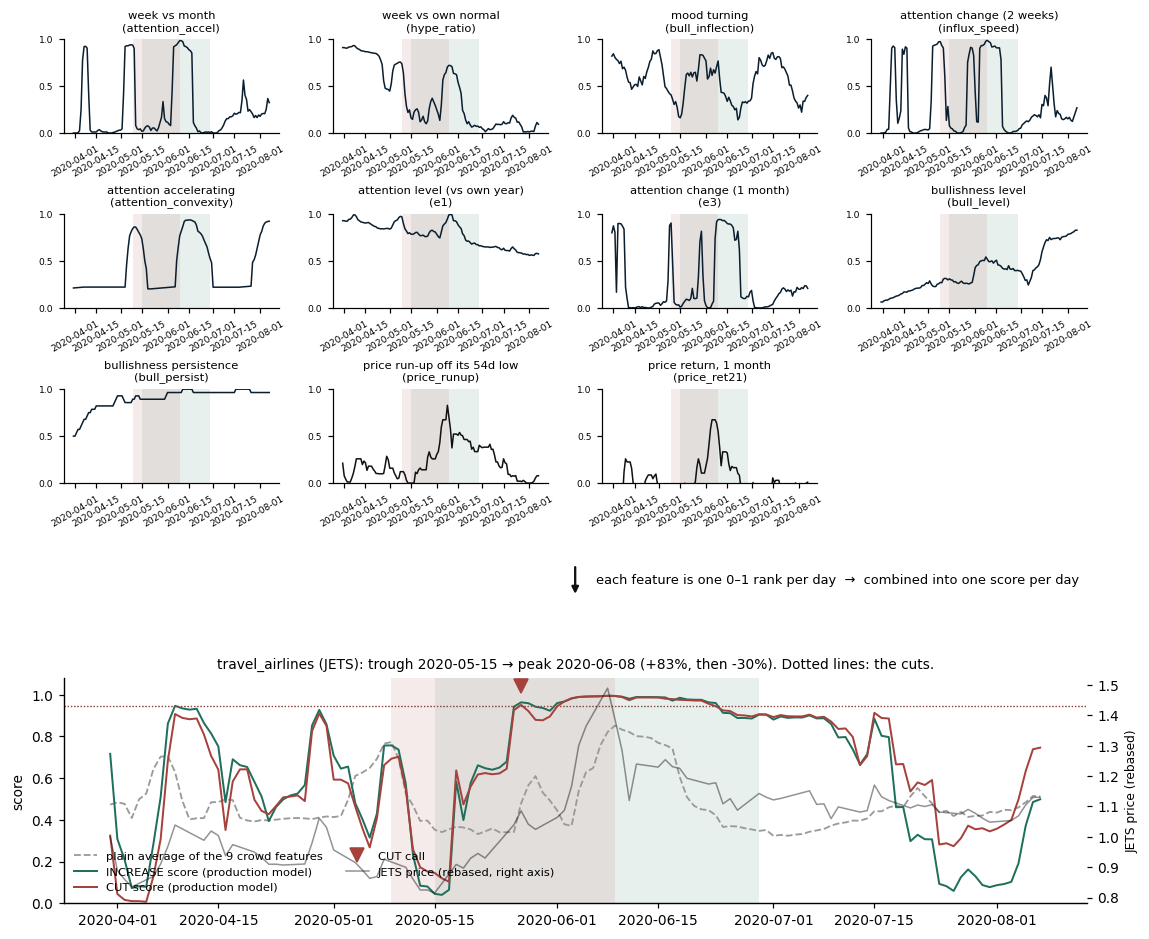

In [19]:
from src.analytics import euphoria_phases as ep, ml_detector as mld

# the judged frame: one row per name per candidate day, all eleven features
prices_, series_, pxmap_, counts_, sents_ = mld._load_all()
episodes_ = ep.episode_catalog(series_, pxmap_)
cand = mld.attach_price_features(mld.candidate_frame(
    ep.build_day_frame(series_, pxmap_, episodes_, counts_, sents_)), series_, pxmap_)
BANK = list(mld.DESK_ML_BANK)
CROWD = [f for f in BANK if not f.startswith("price")]
rep = json.load(open(PROCESSED / "euphoria_desk_report.json"))
desk = pd.read_parquet(PROCESSED / "euphoria_desk.parquet")
labels = json.load(open(PROCESSED / "desk_model_insight.json"))["plain_labels"]

def pick_episode():
    # a theme mania with a CUT call inside the judged window, largest run-up first
    cands = eps[(eps["kind"] == "theme") & eps["top_detectable"]].sort_values("boom_pct", ascending=False)
    for _, e in cands.iterrows():
        d = desk[desk["name"] == e["name"]].set_index("date").sort_index()
        lo, hi = e["trough"] - pd.Timedelta(days=45), e["peak"] + pd.Timedelta(days=60)
        w = d.loc[lo:hi]
        if len(w) < 60 or "get_out" not in w:
            continue
        hits = w.index[w["get_out"].fillna(False).astype(bool)]
        hits = hits[(hits >= e["peak"] - pd.Timedelta(days=30)) & (hits <= e["peak"] + pd.Timedelta(days=1))]
        feats = cand[(cand["name"] == e["name"]) & (cand["date"] >= lo) & (cand["date"] <= hi)]
        if len(hits) and len(feats) >= 40:
            return e, lo, hi
    return None, None, None

ep_, lo_, hi_ = pick_episode()
if ep_ is None:
    print("no episode with a full feature series in this copy")
else:
    f = (cand[(cand["name"] == ep_["name"]) & (cand["date"] >= lo_) & (cand["date"] <= hi_)]
         .set_index("date").sort_index())
    d = desk[desk["name"] == ep_["name"]].set_index("date").sort_index().loc[lo_:hi_]
    p = px[px["symbol"] == ep_["symbol"]].set_index("date")["px_last"].sort_index().loc[lo_:hi_]
    n = len(BANK); ncol = 4; nrow = int(np.ceil(n / ncol))
    fig = plt.figure(figsize=(12, 2.0 * nrow + 4.2))
    gs = fig.add_gridspec(nrow + 2, ncol, height_ratios=[1] * nrow + [0.35, 2.4], hspace=0.75, wspace=0.25)
    def bands(ax):
        ax.axvspan(ep_["trough"], ep_["trough"] + pd.Timedelta(days=45), color=TEAL, alpha=0.10, lw=0)
        ax.axvspan(ep_["peak"] - pd.Timedelta(days=30), ep_["peak"] + pd.Timedelta(days=1), color=BRICK, alpha=0.10, lw=0)
    for i, feat in enumerate(BANK):
        ax = fig.add_subplot(gs[i // ncol, i % ncol])
        bands(ax)
        ax.plot(f.index, f[feat], color=NAVY if feat in CROWD else INK, lw=1.0)
        ax.set_ylim(0, 1); ax.set_yticks([0, 0.5, 1])
        ax.set_title(f"{labels.get(feat, feat)}\n({feat})", fontsize=7.5)
        ax.tick_params(labelsize=6); ax.tick_params(axis="x", labelrotation=30)
    axa = fig.add_subplot(gs[nrow, :]); axa.set_axis_off()
    axa.annotate("", xy=(0.5, 0.0), xytext=(0.5, 1.0), arrowprops=dict(arrowstyle="-|>", lw=1.5, color=INK))
    axa.text(0.52, 0.5, "each feature is one 0–1 rank per day  →  combined into one score per day",
             fontsize=8.5, va="center")
    ax = fig.add_subplot(gs[nrow + 1, :])
    bands(ax)
    ax.plot(f.index, f[CROWD].mean(axis=1), color=GREY, lw=1.2, ls="--", label="plain average of the 9 crowd features")
    ax.plot(d.index, d["in_score"], color=TEAL, lw=1.3, label="INCREASE score (production model)")
    ax.plot(d.index, d["out_score"], color=BRICK, lw=1.3, label="CUT score (production model)")
    ax.axhline(rep["get_in"]["live_threshold"], color=TEAL, lw=0.8, ls=":")
    ax.axhline(rep["get_out"]["live_threshold"], color=BRICK, lw=0.8, ls=":")
    for col, color, mk, lab in (("get_in", TEAL, "^", "INCREASE call"), ("get_out", BRICK, "v", "CUT call")):
        fired = d.index[d[col].fillna(False).astype(bool)]
        if len(fired):
            ax.plot(fired, [1.04] * len(fired), mk, color=color, ms=9, label=lab, clip_on=False)
    ax2 = ax.twinx()
    ax2.plot(p.index, p / p.iloc[0], color=INK, lw=1.0, alpha=0.45, label=f"{ep_['symbol']} price (rebased, right axis)")
    ax2.set_ylabel(f"{ep_['symbol']} price (rebased)", fontsize=8)
    ax.set_ylim(0, 1.08); ax.set_ylabel("score")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="lower left", frameon=False, fontsize=7.5, ncol=2)
    ax.set_title(f"{ep_['name']} ({ep_['symbol']}): trough {ep_['trough'].date()} → peak {ep_['peak'].date()} "
                 f"(+{ep_['boom_pct']:.0%}, then {ep_['bust_pct']:.0%}). Dotted lines: the cuts.", fontsize=9)
    plt.show()

The plain average already rises through the run, but it is a blunt
instrument: it treats every feature as equally important and cannot
tell a start from a top. The model's two heads read the same eleven
inputs with different weights (section 5.2) — the INCREASE head is
already high while the crowd is arriving, the CUT head only once the
run is mature and bullishness has persisted — and a call is made when a
head crosses its cut inside the right phase.

### 6.2 From one number to an occasional call

A score is a number between 0 and 1 for every name every day. Turning it
into an occasional call takes three steps.

**1. The cut.** For each test year, the cut is the score above which the
model fires, and it is chosen on the *training* years only: the value
that maximises episode-level F1 (the balance of precision and the share
of manias caught). Because the cut is chosen before the test year is
seen, the test year's result is out of sample. The cut in use today is
the one fitted on all years before the current one.

**2. The gates and the shape.** A raw crossing would fire on every day
the score wobbles above the cut. So:

* CUT EXPOSURE can only fire once the name has actually boomed (its price
  is above the 120-day boom bar) — the model is asked "is this run
  ending?", not "will there be a run?";
* INCREASE EXPOSURE can only fire before the boom completes;
* after firing, a head re-arms only once the score has fallen back (to
  the cut for CUT, to the training-median score for INCREASE), with at
  least 63 days between calls on the same name, and no INCREASE within
  21 days of a CUT in either direction;
* scores are smoothed over 7 days so a one-day spike does not fire.

**3. Two strictness settings.** Beside the standard F1 cut, a stricter
cut is stored that weights precision twice as much (F0.5). The sweep
below is the trade-off curve between them: as the cut rises, fewer manias
are caught but a larger share of calls are right. The dashboard uses the
standard point; the strict point exists for a reader who prefers fewer,
surer calls.

In [20]:
rep = json.load(open(PROCESSED / "euphoria_desk_report.json"))
thr = pd.DataFrame({"INCREASE cut": rep["get_in"]["walk_forward"]["thresholds"],
                    "CUT cut": rep["get_out"]["walk_forward"]["thresholds"]}).round(3)
thr.index.name = "test year (cut fitted on the years before it)"
print(f"cuts in use now: INCREASE {rep['get_in']['live_threshold']:.3f} (strict {rep['get_in']['strict_threshold']:.3f}); "
      f"CUT {rep['get_out']['live_threshold']:.3f} (strict {rep['get_out']['strict_threshold']:.3f})")
print("operating point rule:", rep["operating_point_rule"])
thr.T

cuts in use now: INCREASE 0.945 (strict 0.971); CUT 0.945 (strict 0.970)
operating point rule: probability cut maximising episode-level F1 on train years


test year (cut fitted on the years before it),2018,2019,2020,2021,2022,2023,2024,2025,2026
INCREASE cut,0.956,0.929,0.913,0.922,0.924,0.897,0.943,0.920,0.945
CUT cut,0.933,0.963,0.966,0.907,0.916,0.945,0.921,0.923,0.945


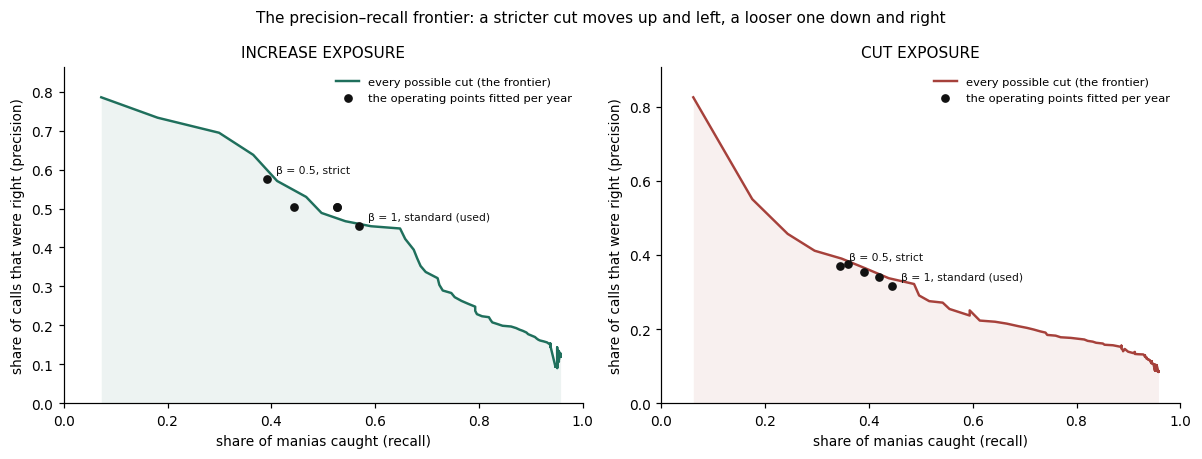

In [21]:
# The frontier: every cut the score can be given, judged the same way as the
# production model (walk-forward scores, one call per name per 21 days, an
# episode caught when a call lands in its judged window).
def frontier(label, mode):
    scored = ep.walk_forward_scores(cand, BANK, label, mld.make_ens_fit(label))
    groups = ep._pregroup(scored, episodes_)
    yrs = sorted(scored["test_year"].unique())
    in_years = lambda e: e.year.isin(yrs)
    out = []
    for thr in np.quantile(scored["score"], np.linspace(0.30, 0.998, 90)):
        r = ep._tally(groups, episodes_, thr, mode, in_years)
        calls = r["captured"] + r["false_alarms"]
        out.append({"cut": thr, "recall": r["captured"] / max(r["detectable"], 1),
                    "precision": r["captured"] / calls if calls else np.nan})
    return pd.DataFrame(out)

fr = {"get_out": frontier("y_top", "top"), "get_in": frontier("y_onset", "onset")}
sweep = pd.DataFrame(record("operating_point_sweep.json"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (head, color, title) in zip(axes, (("get_in", TEAL, "INCREASE EXPOSURE"),
                                          ("get_out", BRICK, "CUT EXPOSURE"))):
    c = fr[head].dropna().sort_values("recall")
    ax.fill_between(c["recall"], 0, c["precision"], color=color, alpha=0.08, lw=0)
    ax.plot(c["recall"], c["precision"], color=color, lw=1.6, label="every possible cut (the frontier)")
    s = sweep[sweep["head"] == head].sort_values("beta")
    ax.scatter(s["capture_rate"], s["precision"], color=INK, zorder=3, s=22, label="the operating points fitted per year")
    for _, r in s.iterrows():
        if r["beta"] in (0.5, 1.0):
            tag = "β = 1, standard (used)" if r["beta"] == 1 else "β = 0.5, strict"
            ax.annotate(tag, (r["capture_rate"], r["precision"]), fontsize=7, color=INK,
                        xytext=(6, 4), textcoords="offset points")
    ax.set_xlabel("share of manias caught (recall)")
    ax.set_ylabel("share of calls that were right (precision)")
    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, max(0.7, float(c["precision"].max()) * 1.1))
    ax.legend(frameon=False, fontsize=7.5, loc="upper right")
fig.suptitle("The precision–recall frontier: a stricter cut moves up and left, a looser one down and right", fontsize=10)
plt.tight_layout()
plt.show()

The curve is every cut the score could be given, from very loose (right:
almost every mania caught, most calls wrong) to very strict (left: few
calls, a larger share of them right). The shaded region is everything
this model can reach; no cut can sit above the line. The black points
are the operating points actually fitted — one cut per test year, chosen
on the training years for a given β — which is why they sit close to
the curve rather than exactly on it. β = 1 (the standard point) weights
precision and recall equally; β = 0.5 (the strict point) weights
precision twice as much. There is no free lunch along the curve: the
choice is where to stand on it, and the dashboard shows the standard
point.

## 7. Performance

All figures are walk-forward test-year results of the production
ensemble, 2018–2026. An INCREASE EXPOSURE call is judged a hit when it
falls inside the 45 days after a mania's trough; a CUT EXPOSURE call when
it falls inside the month before a mania's peak (up to one day after). A
call with no mania around it is a false alarm; a call after the window
is "late" and counts neither way.

* **Episodes caught** — the share of detectable manias with a correct
  call.
* **Median lead** — days between the call and the peak (for CUT) or after
  the trough (for INCREASE).
* **AUROC** — the ranking quality of the daily score.
* **AP vs base rate** — average precision divided by the share of mania
  days; 1× would be no better than chance.
* **Precision** — the share of calls that were right.
* **False alarms per name-year** — how often a name gets a wrong call in
  a year.

In [22]:
def head_row(label, h):
    wf = h["walk_forward"]
    return {"signal": label, "episodes caught": f"{wf['captured']} of {wf['detectable']} ({wf['capture_rate']:.0%})",
            "median lead (days)": wf["median_lead_days"], "AUROC": wf["auroc"],
            "AP": wf["ap"], "base rate": wf["ap_baseline"], "AP vs base rate": f"{wf['ap'] / wf['ap_baseline']:.1f}×",
            "precision": wf["precision"], "false alarms / name-year": wf["fa_per_iy"], "calls": wf["n_alerts"]}
perf = pd.DataFrame([head_row("INCREASE EXPOSURE (starts)", rep["get_in"]),
                     head_row("CUT EXPOSURE (tops)", rep["get_out"])]).set_index("signal")
perf

,episodes caught,median lead (days),AUROC,AP,base rate,AP vs base rate,precision,false alarms / name-year,calls
signal,,,,,,,,,
INCREASE EXPOSURE (starts),173 of 304 (57%),19,0.734,0.257,0.105,2.4×,0.455,0.404,548
CUT EXPOSURE (tops),137 of 308 (44%),14,0.731,0.260,0.095,2.7×,0.317,0.575,506


In [23]:
rows = []
for label, h in (("INCREASE EXPOSURE", rep["get_in"]), ("CUT EXPOSURE", rep["get_out"])):
    for k, v in h["walk_forward"]["forward_returns"].items():
        rows.append({"signal": label, "horizon": k.replace("fwd_", "").replace("d", " trading days"),
                     "calls": v["n"], "median price change after the call": f"{v['median_pct']:+.2f}%",
                     "mean": f"{v['mean_pct']:+.2f}%", "share positive": f"{v['pct_positive']:.0f}%"})
pd.DataFrame(rows).set_index(["signal", "horizon"])

calls median price change after the call     mean share positive
signal            horizon                                                                          
INCREASE EXPOSURE 5 trading days     548                             +0.27%   +2.39%            51%
                  21 trading days    548                             +1.60%   +4.00%            55%
                  84 trading days    544                             +3.99%  +13.76%            56%
CUT EXPOSURE      5 trading days     506                             +0.05%   +2.58%            51%
                  21 trading days    506                             +0.31%   +2.91%            51%
                  84 trading days    501                             +1.48%  +11.36%            52%

Reading the two tables together: roughly half of the manias get a
correct call, with two to three weeks of lead, and the daily score ranks
mania days above ordinary days about three times in four (AUROC ≈ 0.73).
After an INCREASE call the price is more often up than down a month and a
quarter later; after a CUT call the median forward return a month later
is close to zero — the run has stopped, which is what "cut exposure" is
meant to catch, even though many runs then drift rather than crash.

Two caveats travel with every number. First, the sample is small: a few
hundred episodes over nine years, so a capture rate of 45 % carries a
90 % confidence band of roughly ±5 points. Second, the crowd data is thinner
before 2020, so the early test years lean on the price features more
than the later ones do.

### 7.1 The score over one mania

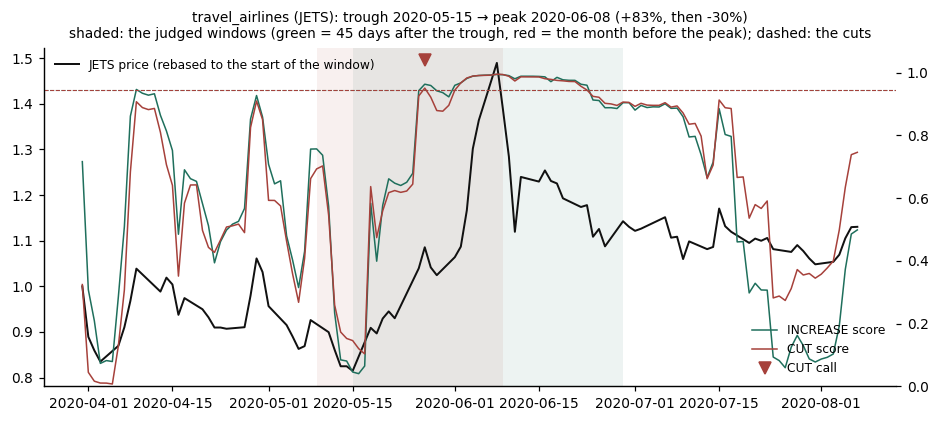

In [24]:
if ep_ is None:
    print("no episode with a full score series in this copy")
else:
    d = desk[desk["name"] == ep_["name"]].set_index("date").sort_index().loc[lo_:hi_]
    p = px[px["symbol"] == ep_["symbol"]].set_index("date")["px_last"].sort_index().loc[lo_:hi_]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(p.index, p / p.iloc[0], color=INK, lw=1.3, label=f"{ep_['symbol']} price (rebased to the start of the window)")
    ax.axvspan(ep_["trough"], ep_["trough"] + pd.Timedelta(days=45), color=TEAL, alpha=0.08, lw=0)
    ax.axvspan(ep_["peak"] - pd.Timedelta(days=30), ep_["peak"] + pd.Timedelta(days=1), color=BRICK, alpha=0.08, lw=0)
    ax2 = ax.twinx()
    ax2.plot(d.index, d["in_score"], color=TEAL, lw=1, label="INCREASE score")
    ax2.plot(d.index, d["out_score"], color=BRICK, lw=1, label="CUT score")
    ax2.axhline(rep["get_in"]["live_threshold"], color=TEAL, lw=0.7, ls="--")
    ax2.axhline(rep["get_out"]["live_threshold"], color=BRICK, lw=0.7, ls="--")
    for col, color, mk, lab in (("get_in", TEAL, "^", "INCREASE call"), ("get_out", BRICK, "v", "CUT call")):
        fired = d.index[d[col].fillna(False).astype(bool)]
        if len(fired):
            ax2.plot(fired, [1.04] * len(fired), mk, color=color, ms=8, label=lab, clip_on=False)
    ax.set_title(f"{ep_['name']} ({ep_['symbol']}): trough {ep_['trough'].date()} → peak {ep_['peak'].date()} "
                 f"(+{ep_['boom_pct']:.0%}, then {ep_['bust_pct']:.0%})\n"
                 "shaded: the judged windows (green = 45 days after the trough, red = the month before the peak); "
                 "dashed: the cuts", fontsize=9)
    ax.legend(loc="upper left", frameon=False, fontsize=8)
    ax2.legend(loc="lower right", frameon=False, fontsize=8)
    ax2.set_ylim(0, 1.08)
    plt.show()

## 8. Appendix: a map of who replies to whom

Separately from the signal above, the project keeps a reply graph: an
edge between two authors whenever one replied to the other, weighted by
how many times. It is used for a different question — which voices are
worth listening to — and nothing in it feeds the INCREASE / CUT model.

Communities are found with the **Louvain method**, which groups nodes so
that there are many more edges inside groups than a random graph with
the same degrees would have (the *modularity* score says how strong that
structure is; 0 means none, above 0.3 is usually called clear
structure). The implementation is the project's own
(`Code/src/analytics/influence_graph.py`), so a copy without a graph library
can still draw it.

The picture shows the most active members of the six largest
communities, coloured by community, with the replies between them. No
author names are shown.

The graph store is built locally from raw replies and is not committed,
so this cell draws the map only on a copy that has run the ingestion.

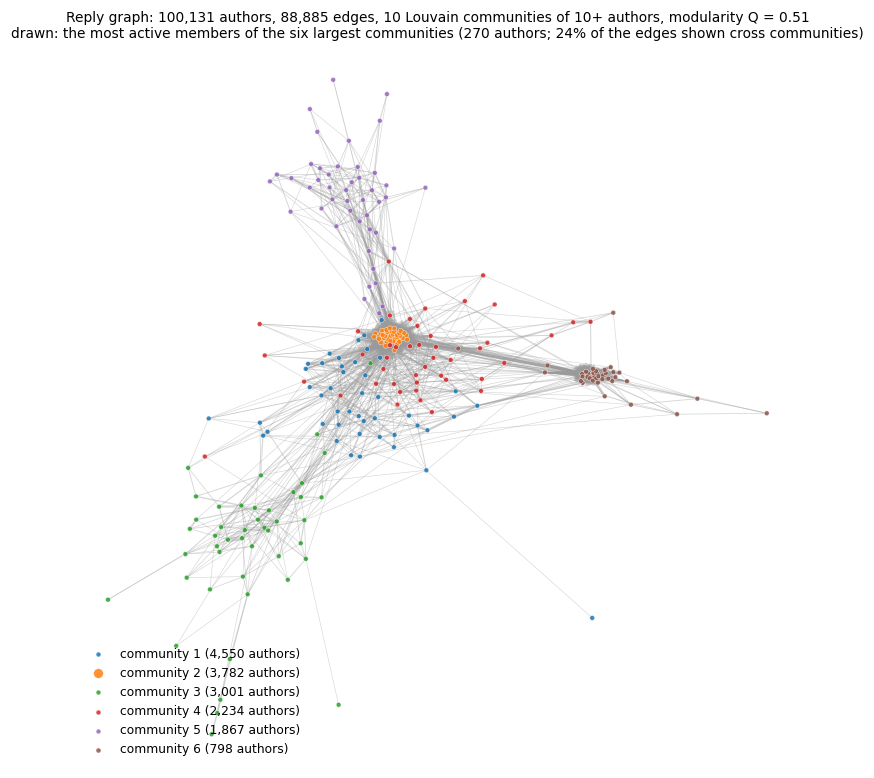

In [25]:
from src.analytics import influence_graph as ig

store = DATA / "reference" / "influence"
if (store / "reply_edges.parquet").exists():
    edges = pd.read_parquet(store / "reply_edges.parquet")
    authors = pd.read_parquet(store / "author_scores.parquet", columns=["author"])["author"]
    g = ig.build_graph(edges, nodes=authors)          # the scored authors and the replies between them
    comm = ig.louvain(g, seed=7)
    q = ig.modularity(g, comm)
    sizes = comm.value_counts()
    strength = pd.Series(np.asarray(g.A.sum(axis=1)).ravel(), index=g.names)
    top_comms = list(sizes.index[:6])
    keep = []
    for c in top_comms:                                # the 45 most active members of each
        keep += list(strength[comm.index[comm == c]].nlargest(45).index)
    sub = g.subgraph(np.array(keep, dtype=object))
    pos = ig.spring_layout(sub)
    el = ig.edge_list(sub)
    cross = float((comm.loc[el["u"]].values != comm.loc[el["v"]].values).mean()) if len(el) else 0.0
    cmap = plt.get_cmap("tab10")
    fig, ax = plt.subplots(figsize=(8.5, 8.5))
    for _, e in el.iterrows():
        ax.plot([pos.loc[e["u"], "x"], pos.loc[e["v"], "x"]],
                [pos.loc[e["u"], "y"], pos.loc[e["v"], "y"]],
                color=GREY, lw=0.3 + 0.1 * e["weight"], alpha=0.4, zorder=1)
    for i, c in enumerate(top_comms):
        members = [n for n in keep if comm[n] == c]
        ax.scatter(pos.loc[members, "x"], pos.loc[members, "y"],
                   s=10 + 60 * (strength[members] / strength[keep].max()),
                   color=cmap(i), alpha=0.85, zorder=2, edgecolors="white", linewidths=0.3,
                   label=f"community {i + 1} ({sizes[c]:,} authors)")
    ax.set_axis_off()
    ax.legend(frameon=False, fontsize=8, loc="lower left")
    ax.set_title(f"Reply graph: {g.n:,} authors, {g.A.nnz // 2:,} edges, "
                 f"{int((sizes >= 10).sum()):,} Louvain communities of 10+ authors, modularity Q = {q:.2f}\n"
                 f"drawn: the most active members of the six largest communities "
                 f"({sub.n} authors; {cross:.0%} of the edges shown cross communities)", fontsize=9)
    plt.show()
else:
    print("no local reply-graph store in this copy; the map is drawn on a copy that has run the ingestion")

The communities are the forums' own conversation clusters (a theme's
regulars reply to each other far more than to outsiders). The influence
work that uses this graph is described in the project's research record
(`Data/research_record/nb05_influence.json`) and surfaces on the
dashboard's influence board; it is a separate tool and makes no
INCREASE / CUT calls.